# Caso Práctico: Predicción de Tendencias de Mercado con Machine Learning

**Curso:** Machine Learning / Deep Learning
**Dataset:** `datos_financieros_100_lineas.csv` (100 registros diarios de la empresa TechCorp)

Pandas y NumPy para el análisis,
Scikit-learn y PyTorch para Machine Learning, NLTK y SciPy para NLP, TensorFlow/Keras para
Deep Learning, y Matplotlib/Seaborn para las visualizaciones.

## 1. Lectura del CSV y transformación de datos (Pandas y NumPy)

In [1]:
import pandas as pd
import numpy as np

datos = pd.read_csv('datos_financieros_100_lineas.csv')
datos

,Fecha,Empresa,Precio_Apertura,Precio_Cierre,Precio_Maximo,Precio_Minimo,Volumen,Ingresos_Millones,Ganancia_Millones,Sentimiento_Reporte,Tendencia
0,2026-01-01,TechCorp,137.45,132.86,140.84,132.13,202424,103.94,19.00,Neutral,Baja
1,2026-01-02,TechCorp,195.07,198.34,199.22,192.18,236141,142.51,26.24,Neutral,Alza
2,2026-01-03,TechCorp,173.20,172.29,174.43,169.36,161888,78.90,18.27,Positivo,Baja
3,2026-01-04,TechCorp,159.87,161.48,166.02,156.50,160448,109.41,17.56,Positivo,Alza
4,2026-01-05,TechCorp,115.60,122.40,125.63,111.83,64397,70.91,8.52,Positivo,Alza
...,...,...,...,...,...,...,...,...,...,...,...
95,2026-04-06,TechCorp,149.38,148.92,152.23,144.23,215650,123.73,24.98,Positivo,Baja
96,2026-04-07,TechCorp,152.27,156.71,160.67,147.91,253196,111.62,24.38,Negativo,Alza
97,2026-04-08,TechCorp,142.75,149.41,150.88,140.32,298683,131.79,23.03,Neutral,Alza
98,2026-04-09,TechCorp,102.54,109.07,112.37,98.66,284677,111.61,12.62,Positivo,Alza


In [2]:
#Revisamos tipos de datos y valores nulos
print(datos.dtypes)
print(datos.isnull().sum())

Fecha                      str
Empresa                    str
Precio_Apertura        float64
Precio_Cierre          float64
Precio_Maximo          float64
Precio_Minimo          float64
Volumen                  int64
Ingresos_Millones      float64
Ganancia_Millones      float64
Sentimiento_Reporte        str
Tendencia                  str
dtype: object
Fecha                  0
Empresa                0
Precio_Apertura        0
Precio_Cierre          0
Precio_Maximo          0
Precio_Minimo          0
Volumen                0
Ingresos_Millones      0
Ganancia_Millones      0
Sentimiento_Reporte    0
Tendencia              0
dtype: int64


In [3]:
#Estadisticas descriptivas basicas
print(datos['Precio_Cierre'].mean())
print(datos['Precio_Cierre'].min())
print(datos['Precio_Cierre'].max())
print(datos['Volumen'].mean())

148.4898
100.83
203.82
179161.25


In [ ]:
#Transformacion: creamos columnas nuevas a partir de las existentes
datos['Variacion'] = datos['Precio_Cierre'] - datos['Precio_Apertura']
datos['Variacion_Pct'] = (datos['Variacion'] / datos['Precio_Apertura']) * 100
datos['Rango_Dia'] = datos['Precio_Maximo'] - datos['Precio_Minimo']
datos

,Fecha,Empresa,Precio_Apertura,Precio_Cierre,Precio_Maximo,Precio_Minimo,Volumen,Ingresos_Millones,Ganancia_Millones,Sentimiento_Reporte,Tendencia,Variacion,Variacion_Pct,Rango_Dia
0,2026-01-01,TechCorp,137.45,132.86,140.84,132.13,202424,103.94,19.00,Neutral,Baja,-4.59,-3.339396,8.71
1,2026-01-02,TechCorp,195.07,198.34,199.22,192.18,236141,142.51,26.24,Neutral,Alza,3.27,1.676321,7.04
2,2026-01-03,TechCorp,173.20,172.29,174.43,169.36,161888,78.90,18.27,Positivo,Baja,-0.91,-0.525404,5.07
3,2026-01-04,TechCorp,159.87,161.48,166.02,156.50,160448,109.41,17.56,Positivo,Alza,1.61,1.007068,9.52
4,2026-01-05,TechCorp,115.60,122.40,125.63,111.83,64397,70.91,8.52,Positivo,Alza,6.80,5.882353,13.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2026-04-06,TechCorp,149.38,148.92,152.23,144.23,215650,123.73,24.98,Positivo,Baja,-0.46,-0.307939,8.00
96,2026-04-07,TechCorp,152.27,156.71,160.67,147.91,253196,111.62,24.38,Negativo,Alza,4.44,2.915873,12.76
97,2026-04-08,TechCorp,142.75,149.41,150.88,140.32,298683,131.79,23.03,Neutral,Alza,6.66,4.665499,10.56
98,2026-04-09,TechCorp,102.54,109.07,112.37,98.66,284677,111.61,12.62,Positivo,Alza,6.53,6.368247,13.71


In [ ]:
#Filtrando: tuDataFrame[condicion]
print(datos[datos['Tendencia'] == 'Alza'].shape[0]) #dias en alza
print(datos[datos['Tendencia'] == 'Baja'].shape[0]) #dias en baja
print(datos[datos['Precio_Cierre'] == datos['Precio_Cierre'].max()]) #dia con precio de cierre mas alto

57
43
         Fecha   Empresa  Precio_Apertura  Precio_Cierre  Precio_Maximo  \
34  2026-02-04  TechCorp           196.56         203.82          205.2   

    Precio_Minimo  Volumen  Ingresos_Millones  Ganancia_Millones  \
34         195.85   278275              73.64                8.2   

   Sentimiento_Reporte Tendencia  Variacion  Variacion_Pct  Rango_Dia  
34             Neutral      Alza       7.26       3.693529       9.35  


In [ ]:
#Agrupando con groupby
datos.groupby('Tendencia')['Volumen'].mean()

Tendencia
Alza    195608.561404
Baja    157359.000000
Name: Volumen, dtype: float64

In [7]:
datos.groupby('Sentimiento_Reporte')['Variacion_Pct'].mean()

Sentimiento_Reporte
Negativo    1.400899
Neutral    -0.275109
Positivo    1.590755
Name: Variacion_Pct, dtype: float64

## 2. Preprocesamiento de datos y validación de modelos

Convertimos las columnas categóricas a numéricas (igual que hicimos con `StandardScaler` en el
código de Iris) y separamos en conjunto de entrenamiento y prueba.

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

#Codificamos la variable objetivo: Alza=1, Baja=0
codificador = LabelEncoder()
datos['Tendencia_Num'] = codificador.fit_transform(datos['Tendencia'])
print(codificador.classes_) #['Alza' 'Baja'] -> 0 y 1

datos[['Tendencia', 'Tendencia_Num']].head()

['Alza' 'Baja']


,Tendencia,Tendencia_Num
0,Baja,1
1,Alza,0
2,Baja,1
3,Alza,0
4,Alza,0


In [9]:
#Variables de entrada (x) y variable objetivo (y)
caracteristicas = ['Precio_Apertura', 'Precio_Cierre', 'Precio_Maximo', 'Precio_Minimo',
                    'Volumen', 'Ingresos_Millones', 'Ganancia_Millones', 'Rango_Dia']

x = datos[caracteristicas].values
y = datos['Tendencia_Num'].values

scaler = StandardScaler()
x_esc = scaler.fit_transform(x) #Normalizamos los valores numericos para el modelo

x_train, x_test, y_train, y_test = train_test_split(x_esc, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)

(80, 8)
(20, 8)


## 3. Modelo de clasificación con Scikit-learn

Usamos un `DecisionTreeClassifier` para predecir si la
tendencia del día será Alza o Baja.

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

modelo_arbol = DecisionTreeClassifier(random_state=42)
modelo_arbol.fit(x_train, y_train)

prediccion = modelo_arbol.predict(x_test)

print('Prediccion del Modelo')
print(prediccion)
print('Etiquetas reales')
print(y_test)

Prediccion del Modelo
[0 1 1 0 1 0 0 1 0 1 1 1 0 0 1 0 0 1 0 1]
Etiquetas reales
[0 0 0 1 1 0 1 1 1 1 0 0 1 1 1 0 0 0 0 1]


In [11]:
#Evaluacion del modelo
exactitud = accuracy_score(y_test, prediccion)
print('Exactitud (accuracy):', exactitud)
print(classification_report(y_test, prediccion, target_names=codificador.classes_))

Exactitud (accuracy): 0.5
              precision    recall  f1-score   support

        Alza       0.50      0.50      0.50        10
        Baja       0.50      0.50      0.50        10

    accuracy                           0.50        20
   macro avg       0.50      0.50      0.50        20
weighted avg       0.50      0.50      0.50        20



In [ ]:
#Prueba individual
muestra_indi = x_test[0].reshape(1, -1)
print('Muestra de prueba seleccionada')
print(muestra_indi)
prediccion_indi = modelo_arbol.predict(muestra_indi)
print('Prediccion del modelo')
print(codificador.classes_[prediccion_indi])
print('Etiqueta real de la muestra')
print(codificador.classes_[y_test[0]])

Muestra de prueba seleccionada
[[-1.37359836 -1.20215116 -1.30690028 -1.38253735  0.3949886   1.24345741
   0.89690392  1.07091255]]
Prediccion del modelo
['Alza']
Etiqueta real de la muestra
Alza


In [13]:
#Validacion del modelo con validacion cruzada (cross validation)
from sklearn.model_selection import cross_val_score

puntajes = cross_val_score(modelo_arbol, x_esc, y, cv=5)
print('Exactitud por cada particion:', puntajes)
print('Exactitud promedio:', puntajes.mean())

Exactitud por cada particion: [0.6  0.65 0.45 0.5  0.8 ]
Exactitud promedio: 0.6


## 4. Red neuronal de clasificación con PyTorch

Esquema: `nn.Sequential`, `CrossEntropyLoss` y `Adam`.

In [14]:
import torch
import torch.nn as nn

x_train_t = torch.tensor(x_train, dtype=torch.float32)
x_test_t = torch.tensor(x_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

model = nn.Sequential(
    nn.Linear(8, 16),   #Capa de entrada (8 caracteristicas)
    nn.ReLU(),           #ReLU para las capas ocultas
    nn.Linear(16, 2)     #Capa de salida: 2 clases (Alza / Baja)
)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
  salida = model(x_train_t)
  loss = loss_fn(salida, y_train_t)

  optimizer.zero_grad() #Limpiamos las gradientes
  loss.backward()       #Retropropagacion
  optimizer.step()       #Ajustamos pesos y sesgo

print('Perdida final:', loss.item())

Perdida final: 0.14232289791107178


In [15]:
#Prueba total del modelo en PyTorch
with torch.no_grad():
  pred_pt = model(x_test_t).argmax(1)

print(pred_pt)
print(y_test_t)

exactitud_pt = (pred_pt == y_test_t).float().mean()
print('Exactitud PyTorch:', exactitud_pt.item())

tensor([0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1])
tensor([0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1])
Exactitud PyTorch: 0.699999988079071


## 5. NLP con NLTK: extracción de reportes y tokenización

Como el CSV no trae texto libre, generamos un pequeño reporte financiero por cada fila
(usando los propios datos: empresa, tendencia, ingresos, ganancia). Sobre ese texto aplicamos
tokenización y limpieza igual que en el ejercicio de clase.

In [16]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt_tab')
nltk.download('stopwords')

#Extraccion de informacion relevante: construimos el reporte financiero en texto
def crear_reporte(fila):
    return (f"El {fila['Fecha']} la empresa {fila['Empresa']} reporto ingresos de "
            f"{fila['Ingresos_Millones']} millones y ganancia de {fila['Ganancia_Millones']} millones. "
            f"El sentimiento del reporte fue {fila['Sentimiento_Reporte']} y la tendencia fue {fila['Tendencia']}.")

datos['Reporte_Texto'] = datos.apply(crear_reporte, axis=1)
print(datos['Reporte_Texto'][0])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...


El 2026-01-01 la empresa TechCorp reporto ingresos de 103.94 millones y ganancia de 19.0 millones. El sentimiento del reporte fue Neutral y la tendencia fue Baja.


[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
stop_words = stopwords.words('spanish')

texto = datos['Reporte_Texto'][0]

tokens = word_tokenize(texto.lower())
print('---Tokens---')
print(tokens)

texto_limpio = [t for t in tokens if t.isalpha() and t not in stop_words]
print('---Texto limpio (sin stopwords)---')
print(texto_limpio)

---Tokens---
['el', '2026-01-01', 'la', 'empresa', 'techcorp', 'reporto', 'ingresos', 'de', '103.94', 'millones', 'y', 'ganancia', 'de', '19.0', 'millones', '.', 'el', 'sentimiento', 'del', 'reporte', 'fue', 'neutral', 'y', 'la', 'tendencia', 'fue', 'baja', '.']
---Texto limpio (sin stopwords)---
['empresa', 'techcorp', 'reporto', 'ingresos', 'millones', 'ganancia', 'millones', 'sentimiento', 'reporte', 'neutral', 'tendencia', 'baja']


## 6. Análisis de sentimiento con Scikit-learn (TF-IDF + Naive Bayes)
Convertimos los reportes a vectores TF-IDF y entrenamos un `MultinomialNB` para predecir el sentimiento
(Positivo / Neutral / Negativo) a partir del texto generado.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

textos = datos['Reporte_Texto']
etiquetas_sent = datos['Sentimiento_Reporte']

x_train_txt, x_test_txt, y_train_sent, y_test_sent = train_test_split(
    textos, etiquetas_sent, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer()
x_train_vect = vectorizer.fit_transform(x_train_txt)
x_test_vect = vectorizer.transform(x_test_txt)

modelo_nb = MultinomialNB()
modelo_nb.fit(x_train_vect, y_train_sent)

prediccion_sent = modelo_nb.predict(x_test_vect)
print(prediccion_sent)

['Positivo' 'Positivo' 'Positivo' 'Positivo' 'Positivo' 'Positivo'
 'Positivo' 'Positivo' 'Positivo' 'Positivo' 'Positivo' 'Positivo'
 'Positivo' 'Positivo' 'Positivo' 'Positivo' 'Positivo' 'Positivo'
 'Positivo' 'Positivo']


In [19]:
from sklearn.metrics import accuracy_score

print('Exactitud del analisis de sentimiento:', accuracy_score(y_test_sent, prediccion_sent))
print(classification_report(y_test_sent, prediccion_sent))

Exactitud del analisis de sentimiento: 0.5
              precision    recall  f1-score   support

    Negativo       0.00      0.00      0.00         2
     Neutral       0.00      0.00      0.00         8
    Positivo       0.50      1.00      0.67        10

    accuracy                           0.50        20
   macro avg       0.17      0.33      0.22        20
weighted avg       0.25      0.50      0.33        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 7. Análisis estadístico con SciPy

Usamos SciPy para comprobar si existe correlación entre el volumen negociado y la ganancia,
y si el volumen promedio difiere entre los días de Alza y de Baja.

In [20]:
from scipy import stats

#Correlacion de Pearson entre Volumen y Ganancia_Millones
correlacion, valor_p = stats.pearsonr(datos['Volumen'], datos['Ganancia_Millones'])
print('Correlacion Volumen vs Ganancia:', correlacion)
print('Valor p:', valor_p)

Correlacion Volumen vs Ganancia: -0.13241083797401387
Valor p: 0.18909814599444408


In [21]:
#Prueba t: comparamos el volumen promedio entre dias de Alza y dias de Baja
volumen_alza = datos[datos['Tendencia'] == 'Alza']['Volumen']
volumen_baja = datos[datos['Tendencia'] == 'Baja']['Volumen']

t_stat, p_valor = stats.ttest_ind(volumen_alza, volumen_baja)
print('Estadistico t:', t_stat)
print('Valor p:', p_valor)

Estadistico t: 2.7085013654888375
Valor p: 0.007977146855364527


## 8. Red neuronal para series temporales con TensorFlow y Keras

Se construye una red LSTM para predecir el precio de cierre de los próximos días a partir
de los últimos 5 días (serie temporal).

In [22]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler

serie = datos['Precio_Cierre'].values.reshape(-1, 1)

scaler_serie = MinMaxScaler()
serie_esc = scaler_serie.fit_transform(serie)

VENTANA = 5

x_serie = []
y_serie = []
for i in range(len(serie_esc) - VENTANA):
    x_serie.append(serie_esc[i:i+VENTANA, 0])
    y_serie.append(serie_esc[i+VENTANA, 0])

x_serie = np.array(x_serie).reshape(-1, VENTANA, 1)
y_serie = np.array(y_serie)

corte = int(len(x_serie) * 0.8)
x_train_s, x_test_s = x_serie[:corte], x_serie[corte:]
y_train_s, y_test_s = y_serie[:corte], y_serie[corte:]

print(x_train_s.shape)
print(x_test_s.shape)

I0000 00:00:1788478008.963253     484 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788478027.216598     484 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788478035.770743     484 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


(76, 5, 1)
(19, 5, 1)


In [23]:
modelo_lstm = keras.Sequential([
    keras.layers.Input(shape=(VENTANA, 1)),
    keras.layers.LSTM(16),
    keras.layers.Dense(1)
])

modelo_lstm.compile(optimizer='adam', loss='mse')

historial = modelo_lstm.fit(x_train_s, y_train_s, epochs=50, verbose=0)

print('Perdida final de entrenamiento:', historial.history['loss'][-1])

Perdida final de entrenamiento: 0.09472980350255966


In [24]:
#Entrenamiento y evaluacion del modelo LSTM
pred_esc = modelo_lstm.predict(x_test_s, verbose=0)
pred_precio = scaler_serie.inverse_transform(pred_esc)
real_precio = scaler_serie.inverse_transform(y_test_s.reshape(-1, 1))

error_mae = np.mean(np.abs(pred_precio - real_precio))
print('Error absoluto medio (MAE):', error_mae)

for real, pred in zip(real_precio[:5], pred_precio[:5]):
    print('Real:', round(real[0], 2), ' Predicho:', round(pred[0], 2))

Error absoluto medio (MAE): 21.570062287983138
Real: 158.81  Predicho: 144.54
Real: 140.11  Predicho: 142.88
Real: 112.77  Predicho: 146.54
Real: 129.45  Predicho: 145.58
Real: 136.1  Predicho: 147.07


## 9. Visualizaciones (Matplotlib y Seaborn)

Gráfico de líneas, histograma, dispersión con línea de tendencia y gráfico comparativo.

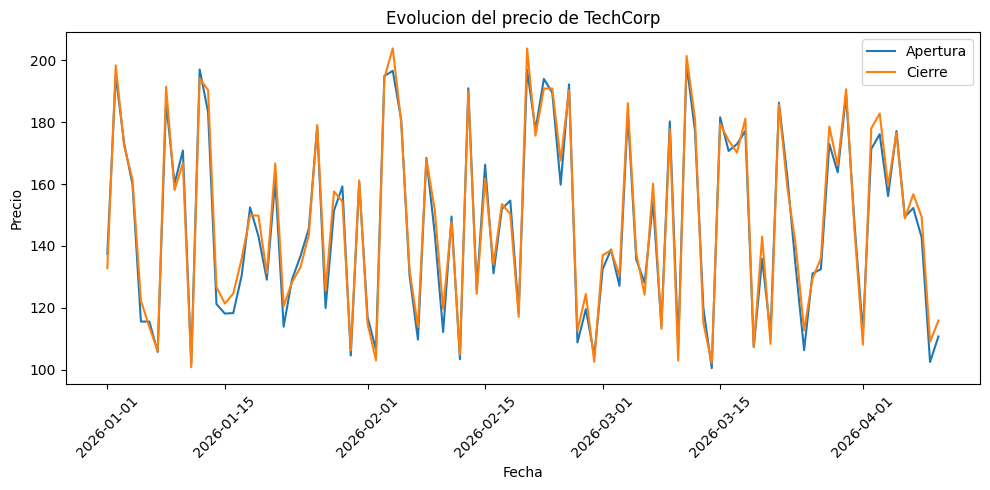

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

datos['Fecha'] = pd.to_datetime(datos['Fecha'])

#Grafico de lineas: evolucion del precio de apertura y cierre
plt.figure(figsize=(10,5))
plt.plot(datos['Fecha'], datos['Precio_Apertura'], label='Apertura')
plt.plot(datos['Fecha'], datos['Precio_Cierre'], label='Cierre')
plt.title('Evolucion del precio de TechCorp')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('grafico_lineas_precio.png', dpi=110)
plt.show()

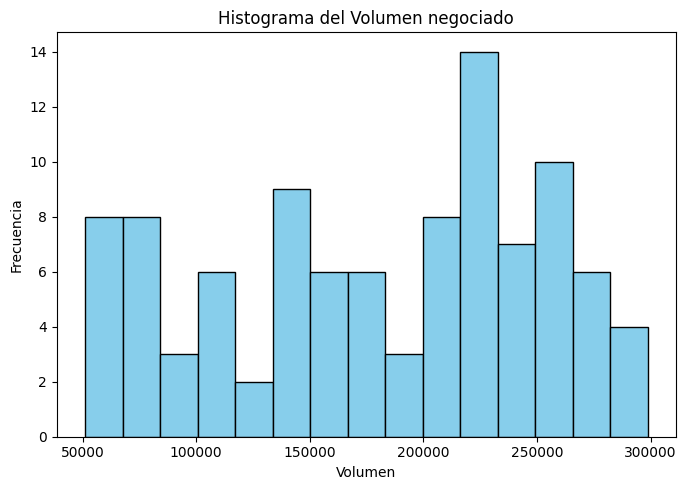

In [26]:
#Histograma del volumen negociado
plt.figure(figsize=(7,5))
plt.hist(datos['Volumen'], bins=15, color='skyblue', edgecolor='black')
plt.title('Histograma del Volumen negociado')
plt.xlabel('Volumen')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('grafico_histograma_volumen.png', dpi=110)
plt.show()

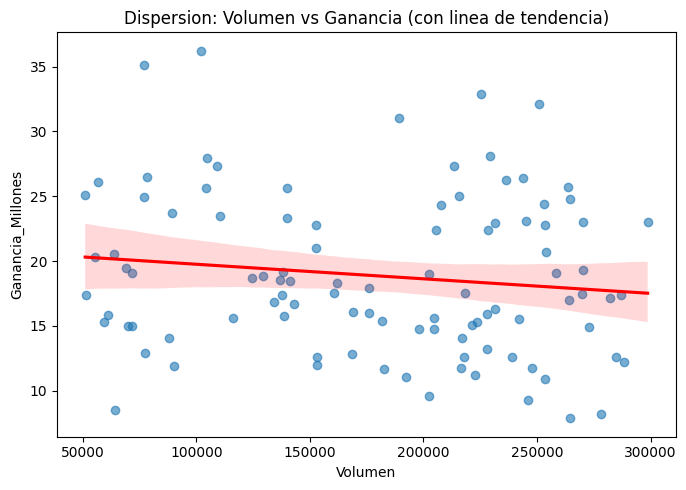

In [27]:
#Grafico de dispersion con linea de tendencia: Volumen vs Ganancia
plt.figure(figsize=(7,5))
sns.regplot(data=datos, x='Volumen', y='Ganancia_Millones',
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Dispersion: Volumen vs Ganancia (con linea de tendencia)')
plt.tight_layout()
plt.savefig('grafico_dispersion_volumen_ganancia.png', dpi=110)
plt.show()

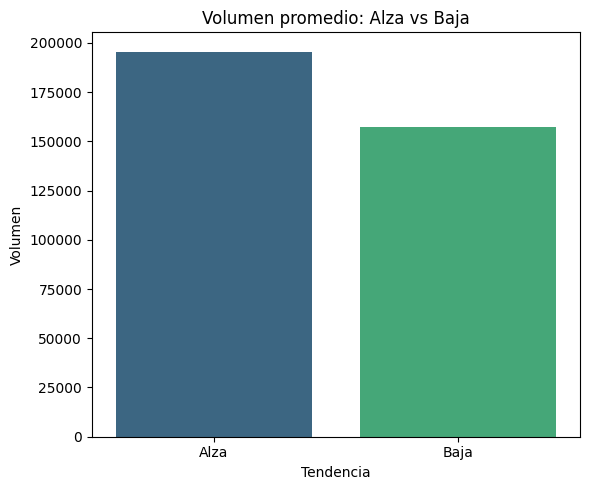

In [28]:
#Grafico comparativo de tendencias de mercado (Alza vs Baja) por volumen promedio
resumen_tendencia = datos.groupby('Tendencia')['Volumen'].mean().reset_index()

plt.figure(figsize=(6,5))
sns.barplot(data=resumen_tendencia, x='Tendencia', y='Volumen', hue='Tendencia',
            palette='viridis', legend=False)
plt.title('Volumen promedio: Alza vs Baja')
plt.tight_layout()
plt.savefig('grafico_comparativo_tendencia.png', dpi=110)
plt.show()

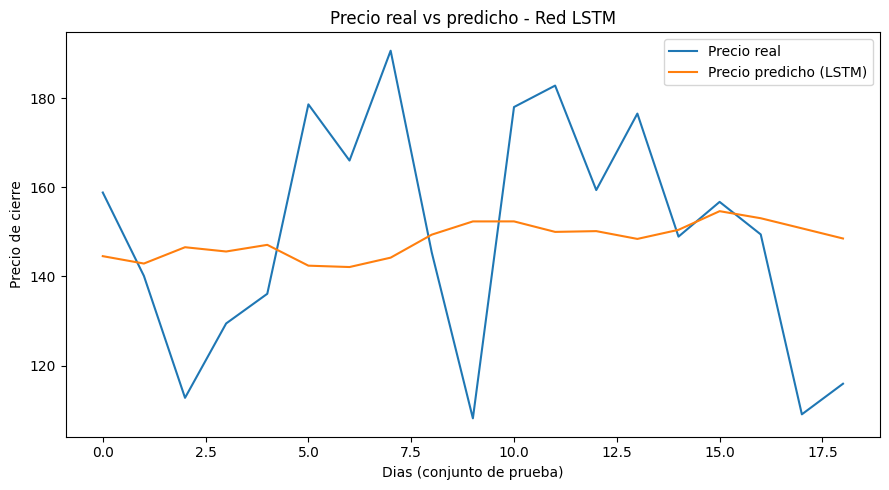

In [29]:
#Grafico real vs predicho de la red LSTM
plt.figure(figsize=(9,5))
plt.plot(real_precio, label='Precio real')
plt.plot(pred_precio, label='Precio predicho (LSTM)')
plt.title('Precio real vs predicho - Red LSTM')
plt.xlabel('Dias (conjunto de prueba)')
plt.ylabel('Precio de cierre')
plt.legend()
plt.tight_layout()
plt.savefig('grafico_lstm_real_vs_predicho.png', dpi=110)
plt.show()

## 10. Conclusiones

- El **DecisionTreeClassifier** (Scikit-learn) y la **red neuronal en PyTorch** clasifican la
  tendencia diaria (Alza/Baja) usando los mismos datos preprocesados y escalados con `StandardScaler`.
- La validación cruzada (`cross_val_score`) confirma que el desempeño del árbol de decisión es
  consistente entre particiones distintas del dataset.
- El modelo **TF-IDF + Naive Bayes** logra extraer el sentimiento del reporte financiero a
  partir del texto generado por fila, aplicando el mismo flujo de tokenización con **NLTK**.
- **SciPy** permitió validar estadísticamente la relación entre volumen y ganancia, y si hay
  diferencias significativas de volumen entre días de Alza y de Baja.
- La red **LSTM en TensorFlow/Keras** predice el precio de cierre a partir de una ventana de
  los últimos 5 días, mostrando cómo un modelo de series temporales aprovecha la dependencia
  temporal de los precios.
- Las visualizaciones con **Matplotlib/Seaborn** (líneas, histograma, dispersión con línea de
  tendencia y gráfico comparativo) resumen el comportamiento del mercado de forma clara para
  el equipo de analistas.